In [106]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from fredapi import Fred
from API_KEY import FRED_API

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 5)

### 1. Create the Fred Object

In [107]:
fred = Fred(api_key=FRED_API)

### 2. Search for Econimic data

In [108]:
sp_search = fred.search('S&P',order_by='popularity')

In [109]:
sp_search

,id,realtime_start,realtime_end,title,observation_start,observation_end,frequency,frequency_short,units,units_short,seasonal_adjustment,seasonal_adjustment_short,last_updated,popularity,notes
series id,,,,,,,,,,,,,,,
BAMLH0A0HYM2,BAMLH0A0HYM2,2026-01-04,2026-01-04,ICE BofA US High Yield Index Option-Adjusted S...,1996-12-31,2025-12-31,"Daily, Close",D,Percent,%,Not Seasonally Adjusted,NSA,2026-01-02 09:07:52-06:00,98,The ICE BofA Option-Adjusted Spreads (OASs) ar...
SP500,SP500,2026-01-04,2026-01-04,S&P 500,2016-01-04,2026-01-02,"Daily, Close",D,Index,Index,Not Seasonally Adjusted,NSA,2026-01-02 19:02:21-06:00,90,The observations for the S&P 500 represent the...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HCIYISFRA066NRUG,HCIYISFRA066NRUG,2026-01-04,2026-01-04,Index of Human Capital per Person for France,1950-01-01,2019-01-01,Annual,A,Index,Index,Not Seasonally Adjusted,NSA,2021-01-21 13:29:25-06:00,4,"Index of human capital per person, based on ye..."
DDDM01RUA156NWDB,DDDM01RUA156NWDB,2026-01-04,2026-01-04,Stock Market Capitalization to GDP for Russian...,2009-01-01,2020-01-01,Annual,A,Percent,%,Not Seasonally Adjusted,NSA,2024-05-07 15:28:13-05:00,4,Total value of all listed shares in a stock ma...


In [110]:
sp_search.shape

(1000, 15)

### 3. Pull Raw Data

In [111]:
sp500 = fred.get_series('SP500')

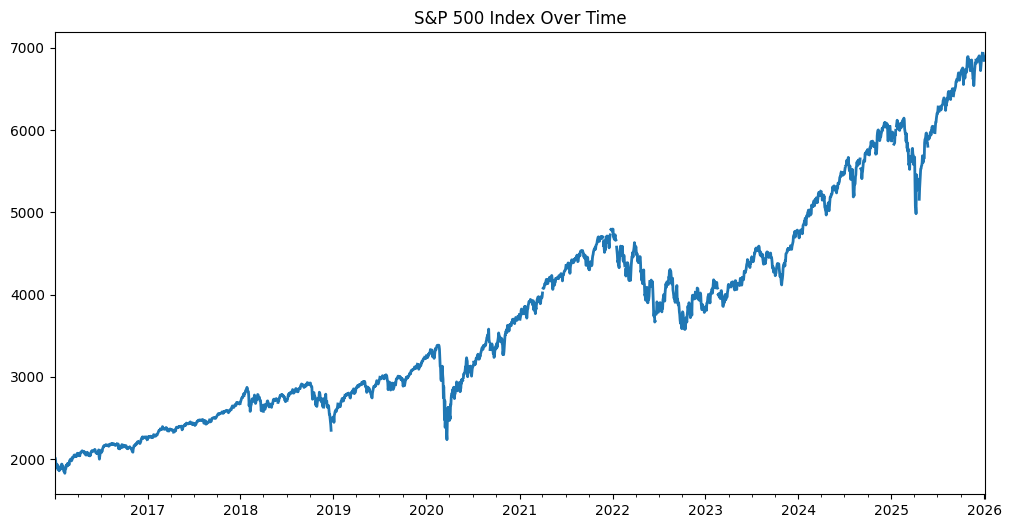

In [112]:
sp500.plot(title='S&P 500 Index Over Time', figsize=(12,6), lw=2)
plt.show()

### 4. Pull and Join Multiple Data Series

In [113]:
unemp_df = fred.search('unemployment rate state', filter=('frequency','Monthly'))
unemp_df = unemp_df.query('seasonal_adjustment == "Seasonally Adjusted" and units == "Percent"')
unemp_df = unemp_df.loc[unemp_df['title'].str.contains('Unemployment Rate')]

In [114]:
all_results = []

for myid in unemp_df.index:
    results = fred.get_series(myid)
    results = results.to_frame(name=myid)
    all_results.append(results)
uemp_results = pd.concat(all_results, axis=1)

In [115]:
cols_to_drop = []
for i in uemp_results:
    if len(i) > 4:
        cols_to_drop.append(i)
uemp_results = uemp_results.drop(columns = cols_to_drop, axis=1)

In [116]:
uemp_states = uemp_results.copy()  #.drop('UNRATE', axis=1)
uemp_states = uemp_states.dropna()
id_to_state = unemp_df['title'].str.replace('Unemployment Rate in ','').to_dict()
uemp_states.columns = [id_to_state[c] for c in uemp_states.columns]

In [117]:
px.line(uemp_states)

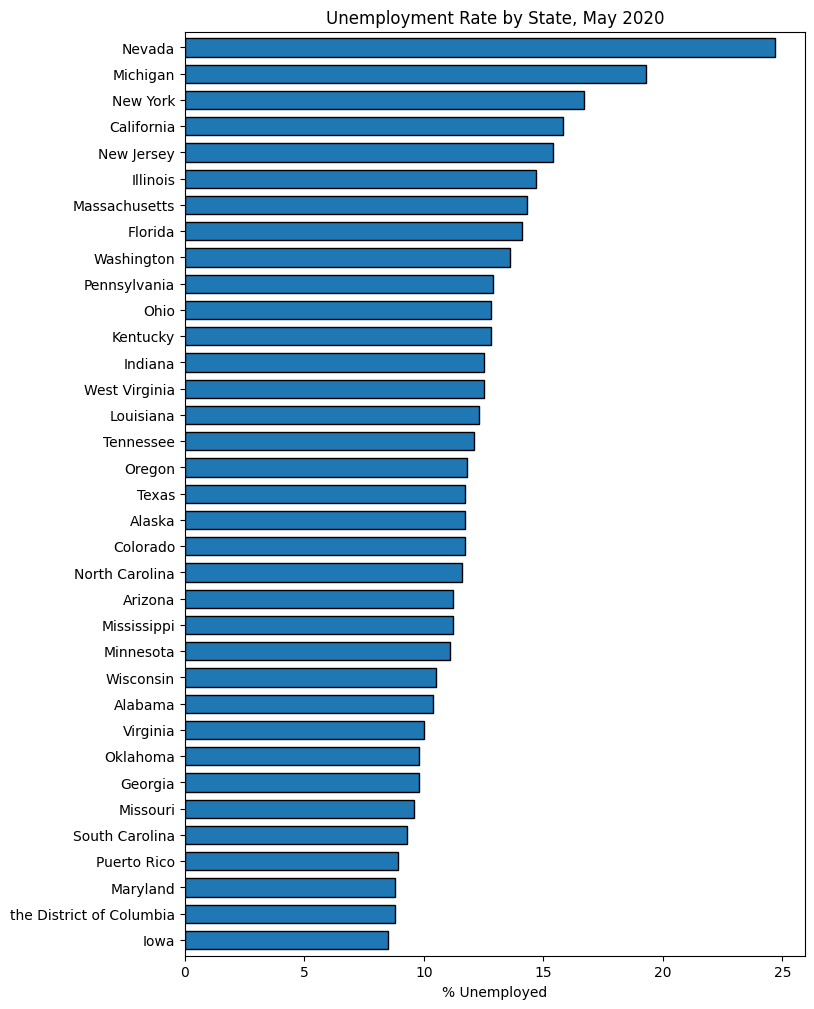

In [118]:
ax = uemp_states.loc[uemp_states.index == '2020-05-01'].T \
    .sort_values('2020-05-01') \
    .plot(kind='barh', figsize=(8, 12), width=0.7, edgecolor='black',
          title='Unemployment Rate by State, May 2020')
ax.legend().remove()
ax.set_xlabel('% Unemployed')
plt.show()

### 4. Participation for each state


In [119]:
part_df = fred.search('participation rate state', filter=('frequency','Monthly'))
part_df = part_df.query('seasonal_adjustment == "Seasonally Adjusted" and units == "Percent"')

In [120]:
part_id_to_state = part_df['title'].str.replace('Labor Force Participation Rate for ','').to_dict()

all_results = []

for myid in part_df.index:
    results = fred.get_series(myid)
    results = results.to_frame(name=myid)
    all_results.append(results)
part_states = pd.concat(all_results, axis=1)
part_states.columns = [part_id_to_state[c] for c in part_states.columns]

### Plot Unemployment vs Participation for each state

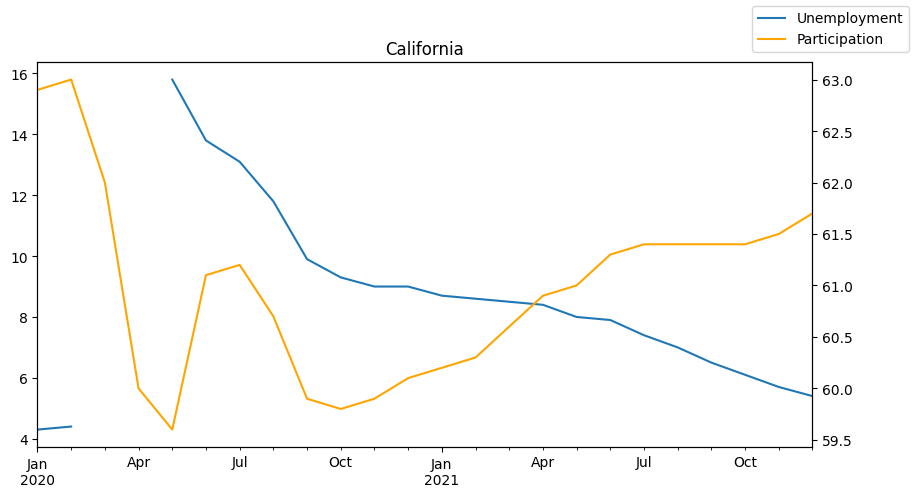

In [121]:
state = 'California'
fig, ax = plt.subplots(figsize=(10, 5), sharex=True)
ax2 = ax.twinx()
uemp_states2 = uemp_states.asfreq('MS')
l1 = uemp_states2.query('index >= 2020 and index < 2022')[state] \
    .plot(ax=ax, label='Unemployment')
l2 = part_states.dropna().query('index >= 2020 and index < 2022')[state] \
    .plot(ax=ax2, label='Participation', color="orange")
ax2.grid(False)
ax.set_title(state)
fig.legend(labels=['Unemployment','Participation'])
plt.show()

In [125]:
uemp_states.columns

Index(['California', 'Texas', 'New York', 'Illinois', 'Alabama', 'Florida',
       'Georgia', 'Michigan', 'Mississippi', 'Ohio', 'Oregon', 'Louisiana',
       'Virginia', 'Massachusetts', 'North Carolina', 'Pennsylvania',
       'New Jersey', 'Kentucky', 'Minnesota', 'Nevada', 'Missouri',
       'Washington', 'Tennessee', 'Colorado', 'Puerto Rico',
       'the District of Columbia', 'Arizona', 'West Virginia', 'Wisconsin',
       'Maryland', 'Indiana', 'Alaska', 'South Carolina', 'Iowa', 'Oklahoma'],
      dtype='object')

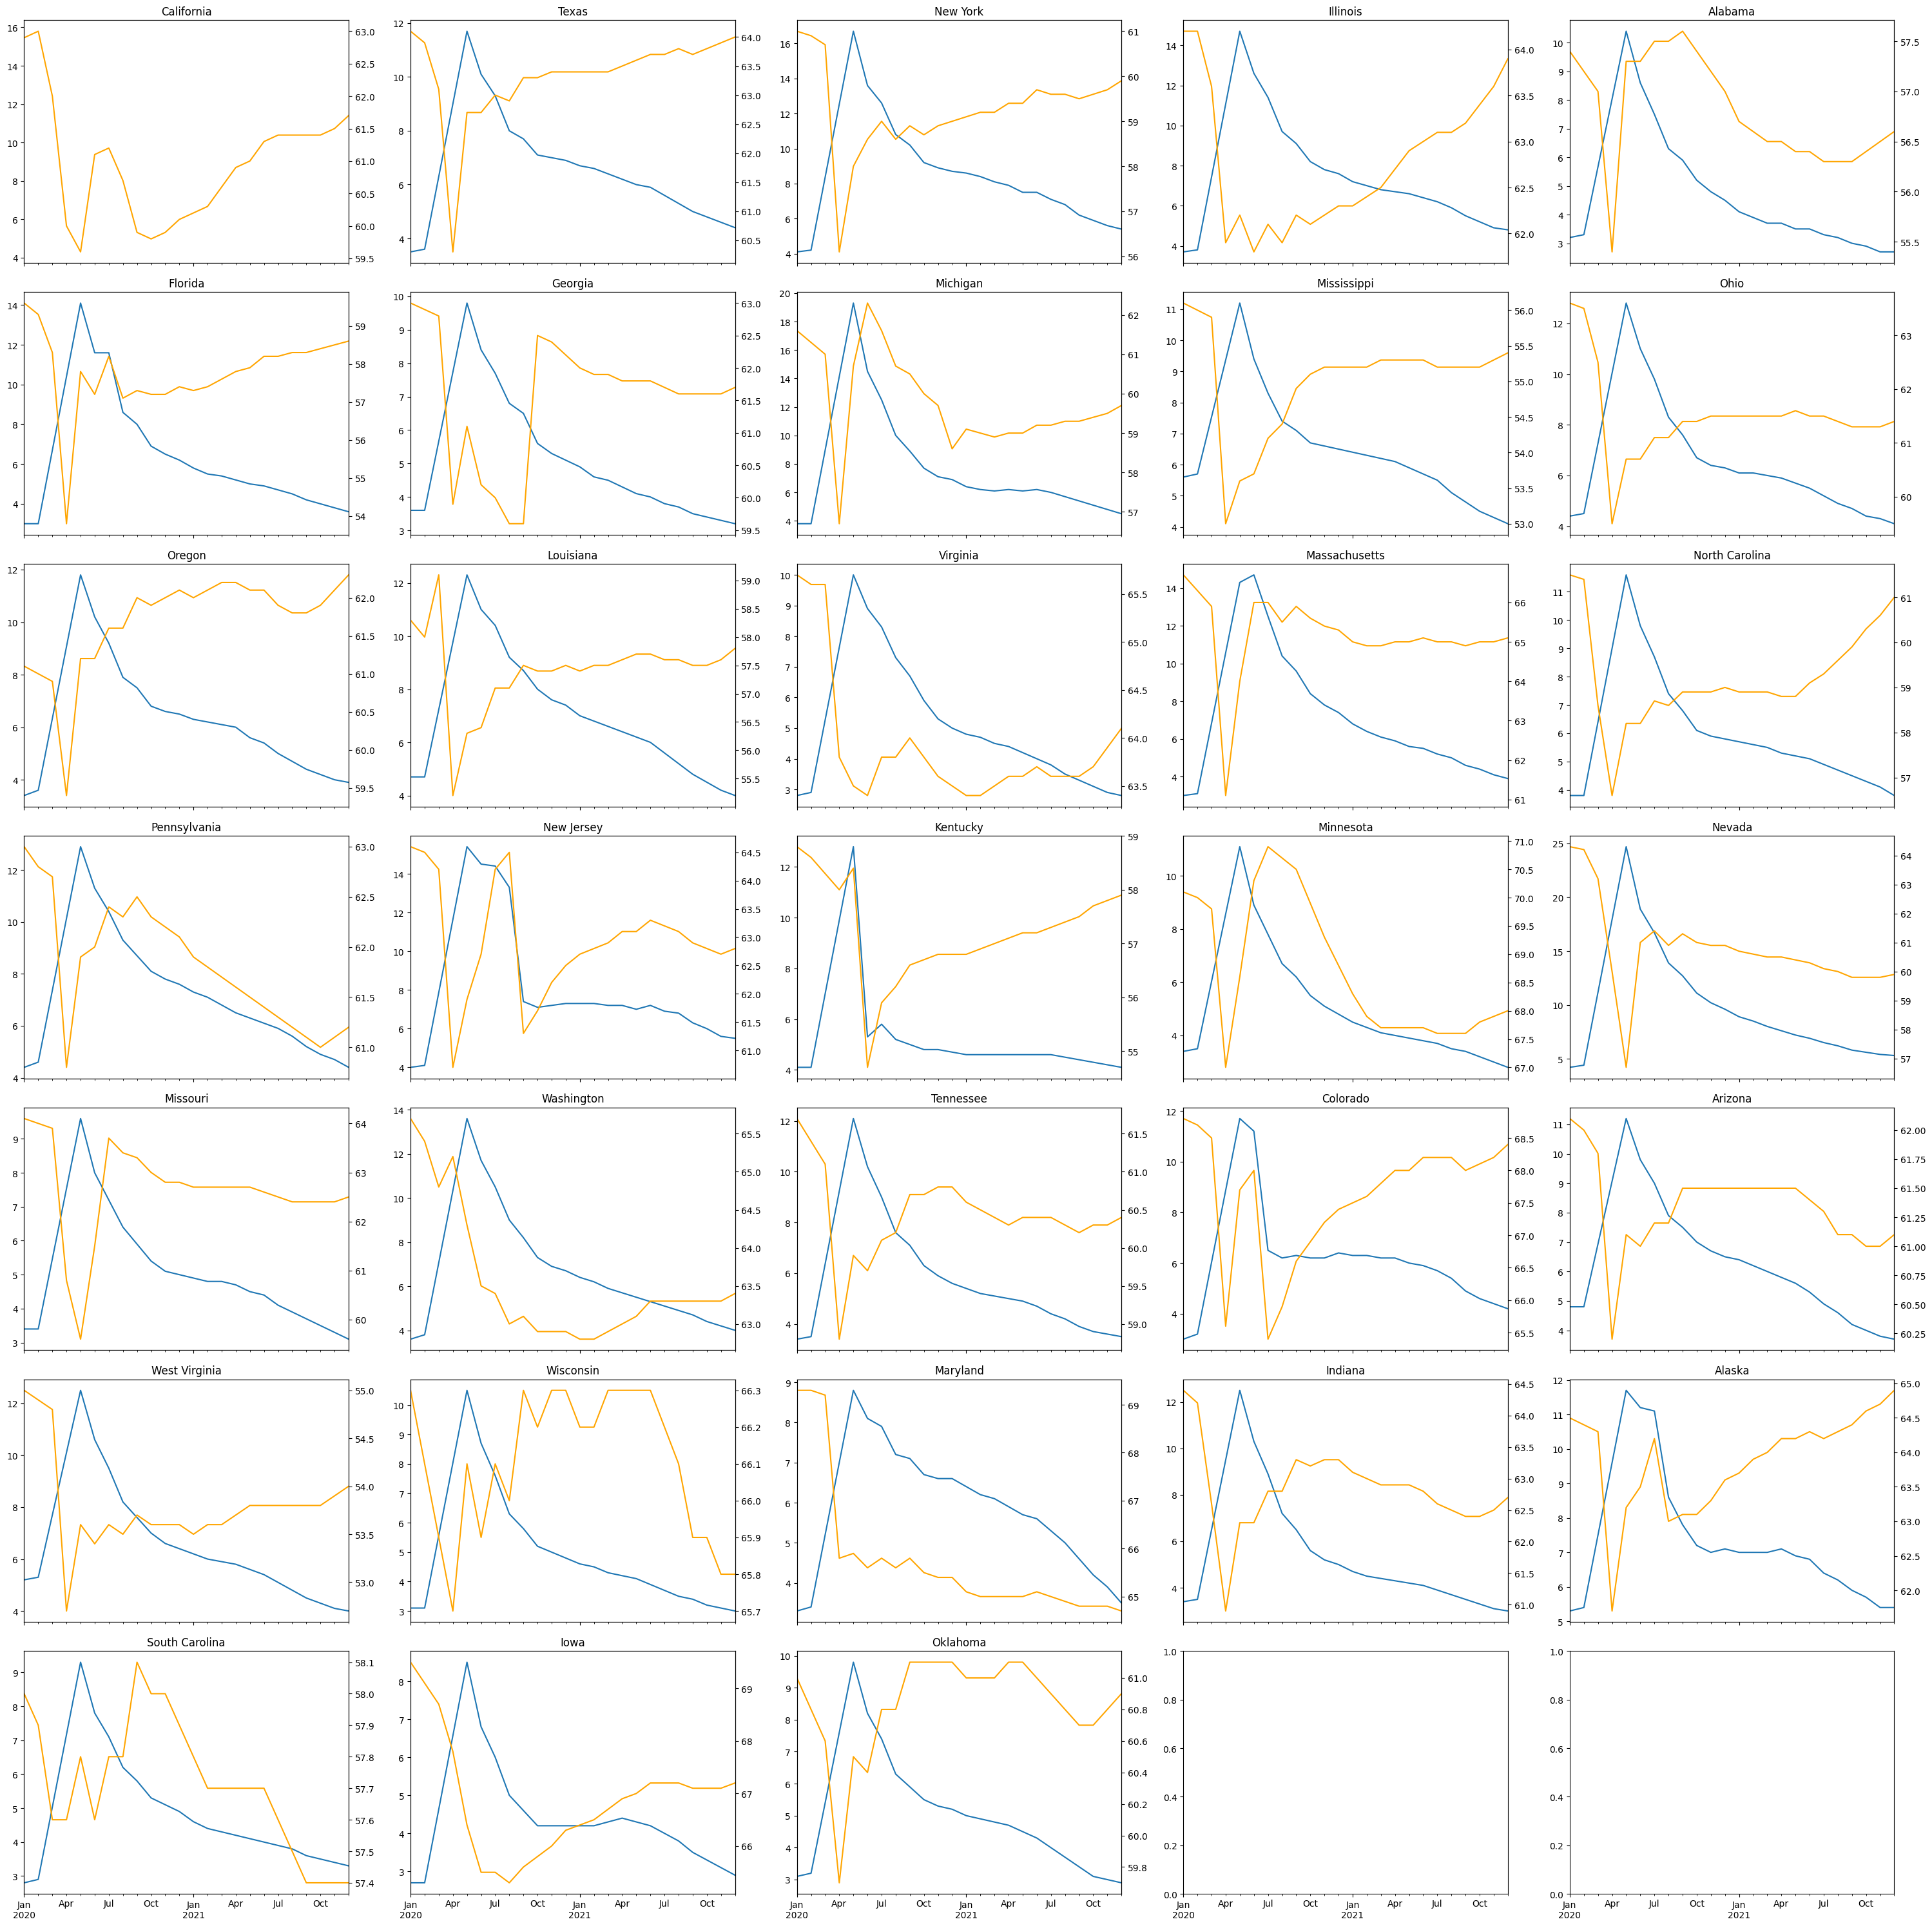

In [127]:
fig, axs = plt.subplots(7, 5, figsize=(30, 30), sharex=True)
axs = axs.flatten()

i = 0
for state in uemp_states.columns:
    if state in ["the District of Columbia","Puerto Rico"]:
        continue
    ax2 = axs[i].twinx()
    uemp_states.query('index >= 2020 and index < 2022')[state] \
        .plot(ax=axs[i], label='Unemployment')
    part_states.query('index >= 2020 and index < 2022')[state] \
        .plot(ax=ax2, label='Participation', color='orange')
    ax2.grid(False)
    axs[i].set_title(state)
    i += 1
plt.tight_layout()
plt.show()